In [2]:
import torchvision 
import torch
import torchvision.transforms as transforms
import os
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/tongpython/cat-and-dog


In [4]:
train_dataset_path = "/kaggle/input/datasets/tongpython/cat-and-dog/training_set/training_set"
test_dataset_path = "/kaggle/input/datasets/tongpython/cat-and-dog/test_set/test_set"

In [5]:
train_transforms = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize( mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

In [6]:
train_dataset = torchvision.datasets.ImageFolder(root = train_dataset_path,transform = train_transforms)
test_dataset = torchvision.datasets.ImageFolder(root = test_dataset_path,transform = test_transforms)

In [7]:
train_loader = torch.utils.data.DataLoader(train_dataset,batch_size = 32,shuffle = True)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size = 32,shuffle = False)

In [8]:
def set_device():
    if torch.cuda.is_available():
        device = 'cuda:0'
    else:
        device = 'cpu'
    return torch.device(device)

print(set_device())


device = set_device()
print(f"Using device : {device} ")

cuda:0
Using device : cuda:0 


In [9]:
# def b_spline_basis(x, knots, k):
#     """
#     x     : [B]
#     knots : [G]
#     k     : degree

#     returns: [B, G-k-1]
#     """
#     B = ((x[:, None] >= knots[:-1]) & (x[:, None] < knots[1:])).float()

#     for d in range(1, k + 1):
#         left_num = x[:, None] - knots[:-d-1]
#         left_den = knots[d:-1] - knots[:-d-1]

#         right_num = knots[d+1:] - x[:, None]
#         right_den = knots[d+1:] - knots[1:-d]

#         left = torch.where(left_den != 0, left_num / left_den, torch.zeros_like(left_den))
#         right = torch.where(right_den != 0, right_num / right_den, torch.zeros_like(right_den))

#         B = left * B[:, :-1] + right * B[:, 1:]

#     return B


In [10]:
# class KANLayer(nn.Module):
#     def __init__(self, in_dim, out_dim, num_knots, k=3):
#         super().__init__()

#         self.in_dim = in_dim
#         self.out_dim = out_dim
#         self.k = k

#         base_knots = torch.linspace(-1, 1, num_knots)
#         h = base_knots[1] - base_knots[0]

#         left_ext = base_knots[0] - h * torch.arange(k, 0, -1)
#         right_ext = base_knots[-1] + h * torch.arange(1, k + 1)

#         # Register knots as a buffer so they are moved to the correct device with the model
#         self.register_buffer('knots', torch.cat([left_ext, base_knots, right_ext]))
#         self.n_basis = len(self.knots) - k - 1

#         self.coef = nn.Parameter(
#             torch.randn(in_dim, out_dim, self.n_basis) * 0.1
#         )

#     def forward(self, x):
#         B_all = []
#         for i in range(self.in_dim):
#             B_i = b_spline_basis(x[:, i], self.knots, self.k)
#             B_all.append(B_i)

#         B = torch.stack(B_all, dim=1)
#         y = torch.einsum('bik,ijk->bj', B, self.coef)
#         return y

In [11]:
# class MultiKAN(nn.Module):
#     def __init__(self, width, num_knots=8, k=3):
#         super().__init__()

#         self.layers = nn.ModuleList()
#         for i in range(len(width) - 1):
#             self.layers.append(
#                 KANLayer(width[i], width[i+1], num_knots, k)
#             )

#     def forward(self, x):
#         for layer in self.layers:
#             x = layer(x)
#         return x


In [12]:
# class MyNN(nn.Module):

#     def __init__(self):
#         super().__init__()

#         self.features = nn.Sequential(

#             nn.Conv2d(3, 16, 3, padding=1),
#             nn.ReLU(),

#             nn.Conv2d(16, 32, 3, padding=1),
#             nn.ReLU(),

#             nn.MaxPool2d(2, 2),

#             nn.Conv2d(32, 64, 3, padding=1),
#             nn.ReLU(),

#             nn.Conv2d(64, 128, 3, padding=1),
#             nn.ReLU(),

#             nn.MaxPool2d(2, 2),

#             nn.AdaptiveAvgPool2d((1, 1))
#         )

#         # KAN
#         self.kan = MultiKAN(
#             width=[128, 257, 1],
#             num_knots=8,
#             k=3
#         )

#     def forward(self, x):

#         x = self.features(x)

#         x = torch.flatten(x, 1)

#         x = self.kan(x)

#         return x

In [18]:
import torch
import torch.nn as nn


# =========================================================
# B-SPLINE BASIS
# =========================================================

def b_spline_basis(x, knots, k):

    B = ((x[:, None] >= knots[:-1]) &
         (x[:, None] < knots[1:])).float()

    for d in range(1, k + 1):

        left_num = x[:, None] - knots[:-d-1]
        left_den = knots[d:-1] - knots[:-d-1]

        right_num = knots[d+1:] - x[:, None]
        right_den = knots[d+1:] - knots[1:-d]

        left = torch.where(
            left_den != 0,
            left_num / left_den,
            torch.zeros_like(left_den)
        )

        right = torch.where(
            right_den != 0,
            right_num / right_den,
            torch.zeros_like(right_den)
        )

        B = left * B[:, :-1] + right * B[:, 1:]

    return B


# =========================================================
# KAN LAYER
# =========================================================

class KANLayer(nn.Module):

    def __init__(self, in_dim, out_dim, num_knots, k=3):

        super().__init__()

        self.in_dim = in_dim
        self.out_dim = out_dim
        self.k = k

        base_knots = torch.linspace(-1, 1, num_knots)

        h = base_knots[1] - base_knots[0]

        left_ext = base_knots[0] - h * torch.arange(k, 0, -1)
        right_ext = base_knots[-1] + h * torch.arange(1, k + 1)

        self.register_buffer(
            'knots',
            torch.cat([left_ext, base_knots, right_ext])
        )

        self.n_basis = len(self.knots) - k - 1

        # SMALLER INITIALIZATION
        self.coef = nn.Parameter(
            torch.randn(
                in_dim,
                out_dim,
                self.n_basis
            ) * 0.001
        )

    def forward(self, x):

        B_all = []

        for i in range(self.in_dim):

            B_i = b_spline_basis(
                x[:, i],
                self.knots,
                self.k
            )

            B_all.append(B_i)

        B = torch.stack(B_all, dim=1)

        y = torch.einsum(
            'bik,ijk->bj',
            B,
            self.coef
        )

        return y


# =========================================================
# MULTI KAN
# =========================================================

class MultiKAN(nn.Module):

    def __init__(self, width, num_knots=8, k=3):

        super().__init__()

        self.layers = nn.ModuleList()

        for i in range(len(width) - 1):

            self.layers.append(
                KANLayer(
                    width[i],
                    width[i + 1],
                    num_knots,
                    k
                )
            )

    def forward(self, x):

        for i, layer in enumerate(self.layers):

            x = layer(x)

            if i != len(self.layers) - 1:
                x = torch.nn.functional.leaky_relu(
                    x,
                    0.1
                )

        return x


# =========================================================
# CNN + KAN MODEL
# =========================================================

class MyNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),

            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),

            nn.MaxPool2d(2, 2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        # IMPORTANT PRE-KAN NORMALIZATION
        self.pre_kan = nn.Sequential(

            nn.BatchNorm1d(128),

            nn.Linear(128, 128),

            nn.Tanh()
        )

        # SMALLER KAN
        self.kan = MultiKAN(
            width=[128, 257, 1],
            num_knots=8,
            k=3
        )

    def forward(self, x):

        x = self.features(x)

        x = torch.flatten(x, 1)

        # IMPORTANT
        x = self.pre_kan(x)

        x = self.kan(x)

        return x

In [13]:
# model = MyNN()
# model =model.to(device)

# loss_function = nn.BCEWithLogitsLoss()
# optimizer = optim.Adam(
#     model.parameters(),
#     lr=0.001,
#     weight_decay=1e-4
# )


In [ ]:
# from tqdm import tqdm

# num_epochs = 50


# train_losses = []


# train_accuracies = []
# val_accuracies = []

# for epoch in range(num_epochs):

#     # =========================
#     # TRAINING
#     # =========================
    
#     model.train()

#     running_loss = 0.0
#     correct = 0
#     total = 0

#     train_bar = tqdm(train_loader)

#     for images, labels in train_bar:
    
#         images = images.to(device)
    
#         labels = labels.float().unsqueeze(1).to(device)
    
#         outputs = model(images)
    
#         loss = loss_function(outputs, labels)
    
#         optimizer.zero_grad()
    
#         loss.backward()
    
#         torch.nn.utils.clip_grad_norm_(
#             model.parameters(),
#             max_norm=1.0
#         )
    
#         optimizer.step()
    
#         running_loss += loss.item()
    
#         predicted = (torch.sigmoid(outputs) > 0.5).float()
    
#         total += labels.size(0)
    
#         correct += (predicted == labels).sum().item()

#          # Update progress bar
#         train_bar.set_description(
#             f"Epoch [{epoch+1}/{num_epochs}] "
#             f"Loss: {loss.item():.4f}"
#         )

#     train_accuracy = 100 * correct / total
#     train_loss = running_loss / len(train_loader)

#     train_losses.append(train_loss)    
#     train_accuracies.append(train_accuracy)

#     print("\n----------------------------------")
#     print(f"Epoch {epoch+1}/{num_epochs}")
#     print(f"Train Loss     : {train_loss:.4f}")
#     print(f"Train Accuracy : {train_accuracy:.2f}%")
#     print("----------------------------------\n")

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm


# =========================================================
# MODEL
# =========================================================

model = MyNN().to(device)


# =========================================================
# LOSS FUNCTION
# =========================================================

loss_function = nn.BCEWithLogitsLoss()


# =========================================================
# OPTIMIZER
# =========================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0003,
    weight_decay=1e-4
)


# =========================================================
# LEARNING RATE SCHEDULER
# =========================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)


# =========================================================
# TRAINING CONFIG
# =========================================================

num_epochs = 50

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_acc = 0.0


# =========================================================
# TRAINING LOOP
# =========================================================

for epoch in range(num_epochs):

    # =====================================================
    # TRAINING
    # =====================================================

    model.train()

    running_loss = 0.0

    correct = 0
    total = 0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{num_epochs}"
    )

    for images, labels in train_bar:

        images = images.to(device)

        labels = labels.float().unsqueeze(1).to(device)

        # Forward
        outputs = model(images)

        loss = loss_function(outputs, labels)

        # Backward
        optimizer.zero_grad()

        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        # Loss
        running_loss += loss.item()

        # Predictions
        probs = torch.sigmoid(outputs)

        predicted = (probs > 0.5).float()

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        # Progress Bar
        train_bar.set_postfix(
            loss=loss.item()
        )

    # =====================================================
    # TRAIN METRICS
    # =====================================================

    train_loss = running_loss / len(train_loader)

    train_accuracy = 100 * correct / total

    train_losses.append(train_loss)

    train_accuracies.append(train_accuracy)


    # =====================================================
    # VALIDATION
    # =====================================================

    model.eval()

    val_running_loss = 0.0

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)

            loss = loss_function(outputs, labels)

            val_running_loss += loss.item()

            probs = torch.sigmoid(outputs)

            predicted = (probs > 0.5).float()

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    # =====================================================
    # VALIDATION METRICS
    # =====================================================

    val_loss = val_running_loss / len(test_loader)

    val_accuracy = 100 * val_correct / val_total

    val_losses.append(val_loss)

    val_accuracies.append(val_accuracy)

    # Scheduler Step
    scheduler.step(val_loss)

    # =====================================================
    # SAVE BEST MODEL
    # =====================================================

    if val_accuracy > best_val_acc:

        best_val_acc = val_accuracy

        torch.save(
            model.state_dict(),
            "best_kan_model.pth"
        )

        print("\nBest model saved!\n")

    # =====================================================
    # PRINT EPOCH RESULTS
    # =====================================================

    print("\n================================================")

    print(f"Epoch {epoch+1}/{num_epochs}")

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Train Accuracy  : {train_accuracy:.2f}%")

    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Validation Acc  : {val_accuracy:.2f}%")

    print("================================================\n")


# =========================================================
# SAVE FINAL MODEL
# =========================================================

torch.save(
    model.state_dict(),
    "final_kan_model.pth"
)

print("Training Completed!")

Epoch 1/50: 100%|██████████| 251/251 [03:53<00:00,  1.08it/s, loss=0.633]



Best model saved!


Epoch 1/50
Train Loss      : 0.6544
Train Accuracy  : 59.74%
Validation Loss : 0.6415
Validation Acc  : 61.34%



Epoch 2/50: 100%|██████████| 251/251 [03:49<00:00,  1.09it/s, loss=0.594]



Best model saved!


Epoch 2/50
Train Loss      : 0.6199
Train Accuracy  : 63.94%
Validation Loss : 0.6028
Validation Acc  : 66.93%



Epoch 3/50: 100%|██████████| 251/251 [03:48<00:00,  1.10it/s, loss=0.526]


...


Epoch 48/50
Train Loss      : 0.3145
Train Accuracy  : 86.26%
Validation Loss : 0.4921
Validation Acc  : 78.60%



Epoch 49/50: 100%|██████████| 251/251 [03:56<00:00,  1.06it/s, loss=0.306]



Epoch 49/50
Train Loss      : 0.3170
Train Accuracy  : 86.05%
Validation Loss : 0.4876
Validation Acc  : 78.40%



Epoch 50/50: 100%|██████████| 251/251 [03:54<00:00,  1.07it/s, loss=0.585]



Epoch 50/50
Train Loss      : 0.3188
Train Accuracy  : 86.26%
Validation Loss : 0.4950
Validation Acc  : 78.45%

Training Completed!


In [20]:
torch.save({

    'epoch': 50,

    'model_state_dict': model.state_dict(),

    'optimizer_state_dict': optimizer.state_dict(),

}, 'con-kan-cot-dag-v6.pth')

In [21]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc
)

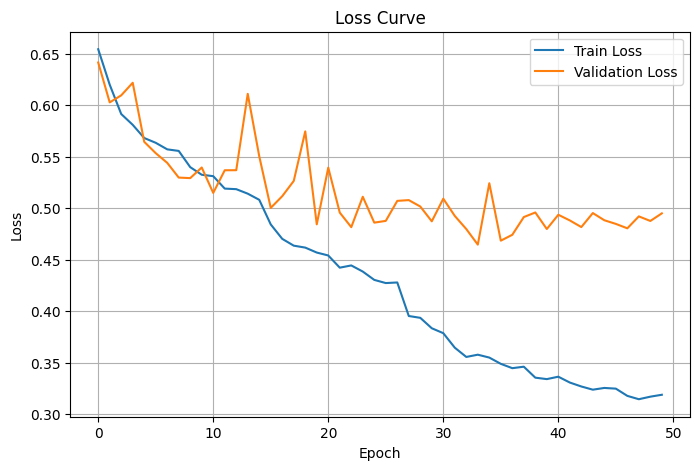

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Loss Curve')

plt.legend()

plt.grid(True)

plt.show()

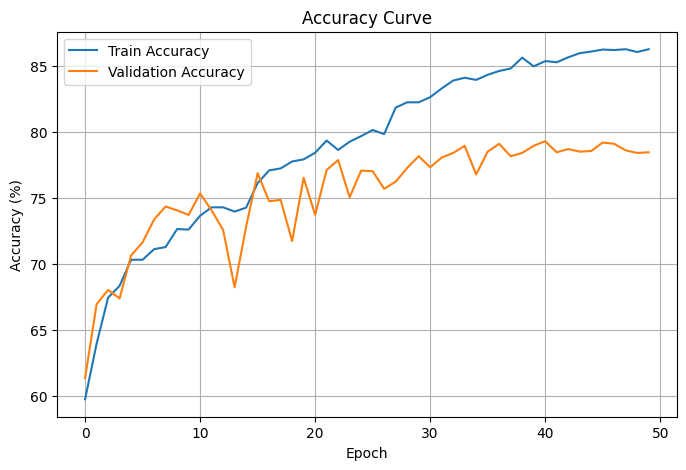

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.title('Accuracy Curve')

plt.legend()

plt.grid(True)

plt.show()

In [24]:
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        all_probs.extend(
            probs.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

In [25]:
import numpy as np

all_probs = np.array(all_probs).flatten()

all_labels = np.array(all_labels)

In [26]:
fpr, tpr, thresholds = roc_curve(
    all_labels,
    all_probs
)

roc_auc = auc(fpr, tpr)

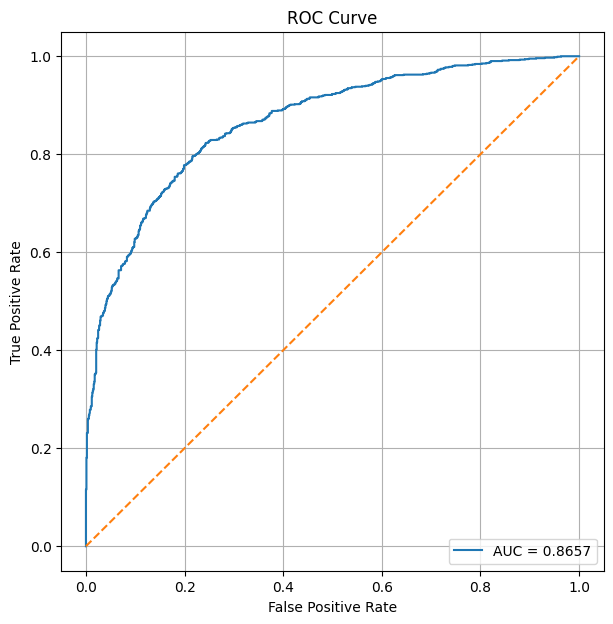

In [27]:
plt.figure(figsize=(7, 7))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend(loc='lower right')

plt.grid(True)

plt.show()

In [28]:
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.8657


In [30]:
from PIL import Image

import matplotlib.pyplot as plt

from torchvision import transforms

In [31]:
transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [32]:
model = MyNN().to(device)

model.load_state_dict(
    torch.load(
        "best_kan_model.pth",
        map_location=device
    )
)

model.eval()

MyNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.1)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): LeakyReLU(negative_slope=0.1)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): LeakyReLU(negative_slope=0.1)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, 

In [33]:
def predict_image(image_path):

    # =========================================
    # LOAD IMAGE
    # =========================================

    image = Image.open(image_path).convert("RGB")

    # =========================================
    # DISPLAY IMAGE
    # =========================================

    plt.imshow(image)
    plt.axis("off")
    plt.show()

    # =========================================
    # TRANSFORM IMAGE
    # =========================================

    image_tensor = transform(image)

    image_tensor = image_tensor.unsqueeze(0)

    image_tensor = image_tensor.to(device)

    # =========================================
    # PREDICTION
    # =========================================

    with torch.no_grad():

        output = model(image_tensor)

        probability = torch.sigmoid(output)

        confidence = probability.item()

        predicted = 1 if confidence > 0.5 else 0

    # =========================================
    # CLASS LABEL
    # =========================================

    class_names = {
        0: "Cat",
        1: "Dog"
    }

    predicted_class = class_names[predicted]

    # =========================================
    # PRINT RESULTS
    # =========================================

    print(f"Prediction : {predicted_class}")

    print(f"Confidence : {confidence:.4f}")

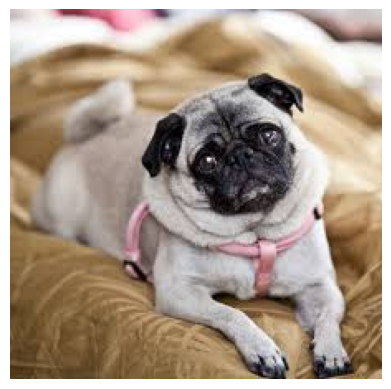

Prediction : Dog
Confidence : 0.9602


In [48]:
predict_image("/kaggle/input/datasets/dynamicdevang/test-images/images (1).jpeg")

In [ ]:
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import torch